# **Titanic**

In [3]:
import pandas as pd


## **1. Data Exploration (EDA)**

In [4]:
df = pd.read_csv('train.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [11]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [12]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [13]:
df.duplicated(subset=['PassengerId']).sum()

np.int64(0)

In [14]:
df['Title'] = df['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [15]:
print("Counts of Survived for Missing Age:")
print(df[df['Age'].isnull()]['Survived'].value_counts())

print("Counts of Survived for Not Missing Age:")
print(df[df['Age'].notnull()]['Survived'].value_counts())

Counts of Survived for Missing Age:
Survived
0    125
1     52
Name: count, dtype: int64
Counts of Survived for Not Missing Age:
Survived
0    424
1    290
Name: count, dtype: int64


In [16]:
missing_age_rate = df[df['Age'].isnull()]['Survived'].mean()
print(f"\nSurvival Rate (Missing Age): {missing_age_rate:.2%}")

known_age_rate = df[df['Age'].notnull()]['Survived'].mean()
print(f"Survival Rate (Known Age): {known_age_rate:.2%}")


Survival Rate (Missing Age): 29.38%
Survival Rate (Known Age): 40.62%


## Visualization

In [17]:
pass 

## **2. Data Cleaning**

In [18]:
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Don', 'Lady', 'Sir', 'Capt', 'the Countess', 'Jonkheer']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

In [19]:
title_ages = df.groupby('Title')['Age'].median()
print(title_ages)

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64


In [20]:
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

In [21]:
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna('S')

In [22]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64


In [23]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [24]:
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,Mrs


In [25]:
df = df.drop(columns=['Name', 'Ticket'])

In [26]:
from sklearn.preprocessing import StandardScaler

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['Age'] = df['Age'].astype(int)

df['Age'] = pd.cut(df['Age'], bins=[-1, 12, 18, 60, 120], labels=[0, 1, 2, 3]).astype(int)

scaler = StandardScaler()
df['Fare'] = scaler.fit_transform(df[['Fare']])

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,1,0,3,0,2,1,0,-0.502445,S,Mr,2
1,2,1,1,1,2,1,0,0.786845,C,Mrs,2
2,3,1,3,1,2,0,0,-0.488854,S,Miss,1
3,4,1,1,1,2,1,0,0.420730,S,Mrs,2
4,5,0,3,0,2,0,0,-0.486337,S,Mr,1


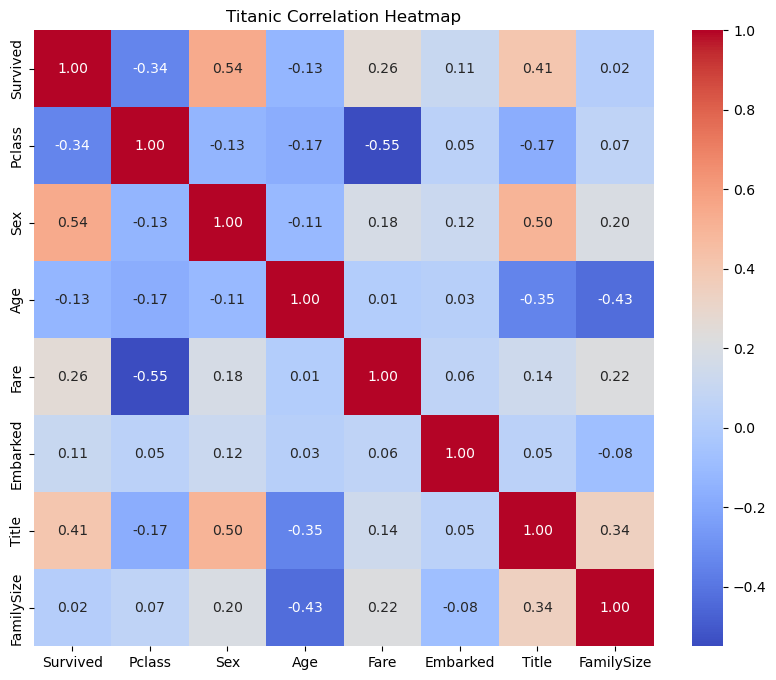

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['Title'] = df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})

df = df.drop(columns=['SibSp', 'Parch', 'PassengerId'])

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Titanic Correlation Heatmap")
plt.show()

## **3. Data Preparation**

In [28]:
X_train = df.drop(columns=['Survived'])
y_train = df['Survived']

## **4. Training MODEL**

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [30]:
log_reg = LogisticRegression(random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier()

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": rf_model,
    "KNN": knn_model
}

print("--- MODEL ACCURACY SCORES (Out of 100%) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (Stability: +/- {scores.std():.4f})")

--- MODEL ACCURACY SCORES (Out of 100%) ---
Logistic Regression: 0.8036 (Stability: +/- 0.0169)
Decision Tree: 0.8103 (Stability: +/- 0.0309)
Random Forest: 0.8104 (Stability: +/- 0.0267)
KNN: 0.8115 (Stability: +/- 0.0289)


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

Grad_Boost = GradientBoostingClassifier(random_state=42)

model = Grad_Boost

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Gradient Boosting Classifier: {scores.mean():.4f} (Stability: +/- {scores.std():.4f})")

Gradient Boosting Classifier: 0.8238 (Stability: +/- 0.0232)


In [32]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"SVM Classifier: {scores.mean():.4f} (Stability: +/- {scores.std():.4f})")

SVM Classifier: 0.8294 (Stability: +/- 0.0236)


## **5. Fine Tuning**

In [33]:
from sklearn.model_selection import GridSearchCV

rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"👑 Best Random Forest: {rf_grid.best_score_:.4f}")

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15], 
    'weights': ['uniform', 'distance'],  
    'p': [1, 2]                          
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"👑 Best KNN Score: {knn_grid.best_score_:.4f}")
print(f"Best KNN Settings: {knn_grid.best_params_}")

gb_params = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f"👑 Best Gradient Boosting: {gb_grid.best_score_:.4f}")

svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1], 'kernel': ['rbf']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f"👑 Best SVM: {svm_grid.best_score_:.4f}")

👑 Best Random Forest: 0.8328
👑 Best KNN Score: 0.8260
Best KNN Settings: {'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
👑 Best Gradient Boosting: 0.8305
👑 Best SVM: 0.8328


## Preparing The Test Dataset

In [34]:
test = pd.read_csv('test.csv')

In [35]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [36]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [37]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [38]:
test['Fare'].median()

14.4542

In [39]:
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

In [40]:
test['Title'] = test['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

test['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [41]:
test['Title'] = test['Title'].replace(['Mlle', 'Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')

rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Don', 'Lady', 'Sir', 'Capt', 'the Countess', 'Jonkheer']
test['Title'] = test['Title'].replace(rare_titles, 'Rare')

In [42]:
test.duplicated(subset=['PassengerId']).sum()

np.int64(0)

In [43]:
test['Age'] = test['Age'].fillna(test.groupby('Title')['Age'].transform('median'))

In [44]:
test['Sex'].unique()

array(['male', 'female'], dtype=object)

In [45]:
test['Sex'] = test['Sex'].map({'female': 1, 'male': 0})
test.head(4)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,S,Mr


In [46]:
test = test.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

In [47]:

test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

test['Age'] = test['Age'].astype(int)

test['Age'] = pd.cut(test['Age'], bins=[-1, 12, 18, 60, 120], labels=[0, 1, 2, 3]).astype(int)

test[['Fare']] = scaler.transform(test[['Fare']])

test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,3,0,2,0,0,-0.490783,Q,Mr,1
1,3,1,2,1,0,-0.507479,S,Mrs,2
2,2,0,3,0,0,-0.453367,Q,Mr,1
3,3,0,2,0,0,-0.474005,S,Mr,1
4,3,1,2,1,1,-0.401017,S,Mrs,3


In [48]:
test = test.drop(columns=['SibSp', 'Parch'])
test.head(10)


,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,3,0,2,-0.490783,Q,Mr,1
1,3,1,2,-0.507479,S,Mrs,2
2,2,0,3,-0.453367,Q,Mr,1
3,3,0,2,-0.474005,S,Mr,1
4,3,1,2,-0.401017,S,Mrs,3
5,3,0,1,-0.462679,S,Mr,1
6,3,1,2,-0.494810,Q,Miss,1
7,2,0,2,-0.064516,S,Mr,3
8,3,1,1,-0.502864,C,Mrs,1
9,3,0,2,-0.162169,S,Mr,3


In [49]:
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Title'] = test['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})
test.head(10)

,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,3,0,2,-0.490783,2,0.0,1
1,3,1,2,-0.507479,0,2.0,2
2,2,0,3,-0.453367,2,0.0,1
3,3,0,2,-0.474005,0,0.0,1
4,3,1,2,-0.401017,0,2.0,3
5,3,0,1,-0.462679,0,0.0,1
6,3,1,2,-0.494810,2,1.0,1
7,2,0,2,-0.064516,0,0.0,3
8,3,1,1,-0.502864,1,2.0,1
9,3,0,2,-0.162169,0,0.0,3


In [50]:
test['Title'].unique()

array([ 0.,  2.,  1.,  3.,  4., nan])

In [51]:
test[test['Title'].isnull()]

,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
414,1,1,2,1.544246,1,NaN,1


In [52]:
test['Title'] = test['Title'].fillna(4)

In [53]:
test['Title'] = test['Title'].astype(int)
test.head(10)

,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,3,0,2,-0.490783,2,0,1
1,3,1,2,-0.507479,0,2,2
2,2,0,3,-0.453367,2,0,1
3,3,0,2,-0.474005,0,0,1
4,3,1,2,-0.401017,0,2,3
5,3,0,1,-0.462679,0,0,1
6,3,1,2,-0.494810,2,1,1
7,2,0,2,-0.064516,0,0,3
8,3,1,1,-0.502864,1,2,1
9,3,0,2,-0.162169,0,0,3


## **6. Testing + Evaluation**

In [54]:
final_model = rf_grid.best_estimator_
final_model_second = svm_grid.best_estimator_

predictions = final_model.predict(test)
predictions_second = final_model_second.predict(test)

original_test_data = pd.read_csv('test.csv')

submission = pd.DataFrame({
    "PassengerId": original_test_data["PassengerId"],
    "Survived": predictions
})

submission_second = pd.DataFrame({
    "PassengerId": original_test_data["PassengerId"],
    "Survived": predictions_second
})

# 4. Save to CSV
submission.to_csv('submission.csv', index=False)
submission_second.to_csv('submission_second.csv', index=False)
print("🎉 FILES CREATED SUCCESSFULLY! 🎉")

🎉 FILES CREATED SUCCESSFULLY! 🎉


In [55]:
rfcheck = pd.read_csv('submission.csv')
svmcheck = pd.read_csv('submission_second.csv')

In [56]:
rfcheck['Survived'].value_counts()

Survived
0    267
1    151
Name: count, dtype: int64

In [57]:
svmcheck['Survived'].value_counts()

Survived
0    279
1    139
Name: count, dtype: int64